# New Metabolic Genes Functional Analysis

Functional characterization of **~307 new metabolic genes** added to the *E. coli* whole-cell model.

Three analyses are performed in order:
1. **GO Enrichment** – goatools with EcoCyc GAF + gseapy Enrichr as a complementary approach
2. **KEGG Pathway Enrichment** – KEGG REST API, Fisher exact test, BH-FDR correction
3. **RegulonDB Regulon Mapping** – TF-gene network, enrichment, and category summary

Output figures are saved to `figures/` and temporary downloads to `tmp/` (both relative to the notebook location).

In [1]:
import importlib, subprocess

for pkg in ["goatools", "gseapy", "statsmodels", "requests"]:
    if importlib.util.find_spec(pkg) is None:
        print(f"Installing {pkg}...")
        subprocess.run(["uv pip", "install", "-q", pkg], check=True)
        print(f"  {pkg} installed.")
    else:
        print(f"  {pkg} already available.")

Installing goatools...


FileNotFoundError: [Errno 2] No such file or directory: 'uv pip'

In [2]:
import ast
import pandas as pd
from pathlib import Path

outdir = Path("out/new_genes_functionality")
outdir.mkdir(exist_ok=True)

tmpdir = Path("tmp")
tmpdir.mkdir(exist_ok=True)

csv_path = Path("new_metabolic_gene_annotation.csv")
df = pd.read_csv(csv_path)

for col in ["Reactions", "MultiFuntional name"]:
    df[col] = df[col].apply(
        lambda x: ast.literal_eval(x)
        if isinstance(x, str) and x.strip().startswith("[")
        else x
    )

study_ecocyc_ids  = set(df["Gene ID (EcoCyc)"].dropna().str.strip())
study_locus_ids   = set(df["Gene locus ID"].dropna().str.strip())
study_gene_names  = set(df["Gene name"].dropna().str.strip().str.lower())

print(f"Loaded {len(df)} gene annotations")
print(f"  EcoCyc IDs : {len(study_ecocyc_ids)}")
print(f"  Locus IDs  : {len(study_locus_ids)}")
print(f"  Gene names : {len(study_gene_names)}")
df.head(3)

Loaded 307 gene annotations
  EcoCyc IDs : 307
  Locus IDs  : 307
  Gene names : 307


,Gene ID (EcoCyc),Gene locus ID,Gene name,Enzyme encoded,Pathways,Pathways parent,Protein products,MultiFuntional ID,MultiFuntional name,Reactions,Description by Cyrus
0,EG10022,b4015,aceA,ISOCIT-LYASE,GLYOXYLATE-BYPASS,Energy-Metabolism,ISOCIT-LYASE-MONOMER,BC-1.7.2,[metabolism -> central intermediary metabolism...,[ISOCIT-CLEAV-RXN],acetate transport + metabolism
1,EG10023,b4014,aceB,MALATE-SYNTHASE,GLYOXYLATE-BYPASS,Energy-Metabolism,MALATE-SYNTHASE,BC-1.7.2,[metabolism -> central intermediary metabolism...,[MALSYN-RXN],acetate transport + metabolism
2,EG11942,b4067,actP,CPLX0-7955,NaN,NaN,YJCG-MONOMER,"['BC-4.2.A', 'BC-6.1']",[transport -> Electrochemical potential driven...,"[RXN0-1981, RXN0-5111, TRANS-RXN0-576]",acetate transport + metabolism


## 1. GO Enrichment Analysis

In [3]:
import requests, gzip, io

gaf_path = tmpdir / "ecocyc.gaf"
obo_path = tmpdir / "go-basic.obo"

if not gaf_path.exists():
    print("Downloading EcoCyc GAF annotation file...")
    try:
        r = requests.get(
            "http://current.geneontology.org/annotations/ecocyc.gaf.gz",
            timeout=180,
        )
        r.raise_for_status()
        with gzip.open(io.BytesIO(r.content)) as fgz:
            content = fgz.read()
        gaf_path.write_bytes(content)
        print(f"  Saved {gaf_path} ({gaf_path.stat().st_size // 1024} KB)")
    except Exception as e:
        print(f"  WARNING: GAF download failed: {e}")
        gaf_path = None
else:
    print(f"Using cached GAF: {gaf_path}")

if not obo_path.exists():
    print("Downloading GO OBO file...")
    try:
        r = requests.get(
            "http://purl.obolibrary.org/obo/go/go-basic.obo",
            timeout=180,
        )
        r.raise_for_status()
        obo_path.write_bytes(r.content)
        print(f"  Saved {obo_path} ({obo_path.stat().st_size // 1024} KB)")
    except Exception as e:
        print(f"  WARNING: OBO download failed: {e}")
        obo_path = None
else:
    print(f"Using cached OBO: {obo_path}")

Using cached GAF: tmp/ecocyc.gaf
Using cached OBO: tmp/go-basic.obo


In [8]:
import collections

go_df = pd.DataFrame()
go_results_by_ns = {}

if gaf_path is not None and obo_path is not None:
    from goatools.obo_parser import GODag
    from goatools.anno.gaf_reader import GafReader
    from goatools.go_enrichment import GOEnrichmentStudy

    print("Loading GO DAG...")
    godag = GODag(str(obo_path))

    print("Loading GAF annotations...")
    gaf_reader = GafReader(str(gaf_path))
    # EcoCyc GAF uses EcoCyc gene IDs (e.g. EG10022) as db_object_id
    ns2assc = gaf_reader.get_ns2assc()

    gene2go = collections.defaultdict(set)
    for ns_assc in ns2assc.values():
        for gid, goterms in ns_assc.items():
            gene2go[gid].update(goterms)

    all_background = set(gene2go.keys()) # all ecoli genes with GO annotations in the GAF
    sample = list(all_background)[:5]
    print(f"Background: {len(all_background)} genes (sample IDs: {sample})")

    # Build symbol -> ID fallback mapping from GAF records
    sym2id = {}
    for rec in gaf_reader.get_associations():
        sym2id[rec.DB_Symbol.lower()] = rec.DB_ID
    matched_study = {sym2id[n] for n in study_gene_names if n in sym2id}
    print(f"Matched by gene symbol: {len(matched_study)}")

    print(f"\nRunning GO enrichment: {len(matched_study)} study vs {len(all_background)} background...")
    goeaobj = GOEnrichmentStudy(
        list(all_background),
        dict(gene2go),
        godag,
        propagate_counts=False,
        alpha=0.05,
        methods=["fdr_bh"],
    )
    results = goeaobj.run_study(matched_study)

    sig_results = [
        r for r in results
        if r.p_fdr_bh < 0.05 and r.ratio_in_study[0] > 0
    ]
    print(f"\nSignificant GO terms (FDR < 0.05): {len(sig_results)}")

    for r in sig_results:
        go_results_by_ns.setdefault(r.NS, []).append(r)
    for ns, rlist in go_results_by_ns.items():
        print(f"  {ns}: {len(rlist)} terms")

    rows = []
    for r in sig_results:
        rows.append({
            "GO_ID": r.GO,
            "term": r.goterm.name,
            "namespace": r.NS,
            "p_uncorrected": r.p_uncorrected,
            "p_fdr_bh": r.p_fdr_bh,
            "study_count": r.ratio_in_study[0],
            "study_total": r.ratio_in_study[1],
            "pop_count": r.ratio_in_pop[0],
            "pop_total": r.ratio_in_pop[1],
        })
    go_df = pd.DataFrame(rows).sort_values("p_fdr_bh")
    print("\nTop 10 enriched GO terms:")
    print(go_df.head(10)[["GO_ID", "term", "namespace", "study_count", "p_fdr_bh"]].to_string(index=False))
else:
    print("Skipping goatools analysis: required files unavailable.")

Loading GO DAG...
tmp/go-basic.obo: fmt(1.2) rel(2026-03-25) 41,853 Terms
Loading GAF annotations...
HMS:0:00:00.516491  53,196 annotations READ: tmp/ecocyc.gaf 
Background: 7167 genes (sample IDs: ['CPX-1974', 'EG11838-MONOMER', 'G7084-MONOMER', 'EG12325-MONOMER', 'P63340'])
Matched by gene symbol: 306

Running GO enrichment: 306 study vs 7167 background...

Load  Ontology Enrichment Analysis ...
100%  7,167 of  7,167 population items found in association

Runing  Ontology Analysis: current study set of 306 IDs.
100%    306 of    306 study items found in association
100%    306 of    306 study items found in population(7167)
Calculating 4,094 uncorrected p-values using fisher_scipy_stats
   4,094 terms are associated with  7,167 of  7,167 population items
     424 terms are associated with    306 of    306 study items
  METHOD fdr_bh:
      19 GO terms found significant (< 0.05=alpha) ( 11 enriched +   8 purified): statsmodels fdr_bh
      49 study items associated with significant GO

In [9]:
go_df.head()

,GO_ID,term,namespace,p_uncorrected,p_fdr_bh,study_count,study_total,pop_count,pop_total
13,GO:0005515,protein binding,MF,1.233026e-12,5.048008e-09,11,306,1176,7167
11,GO:0005829,cytosol,CC,1.122336e-07,1.148711e-04,31,306,1544,7167
0,GO:0009401,phosphoenolpyruvate-dependent sugar phosphotra...,BP,6.598248e-07,4.704404e-04,17,306,98,7167
1,GO:0033214,siderophore-iron import into cell,BP,6.894583e-07,4.704404e-04,9,306,26,7167
2,GO:0019700,organic phosphonate catabolic process,BP,1.048459e-06,6.131986e-04,6,306,10,7167


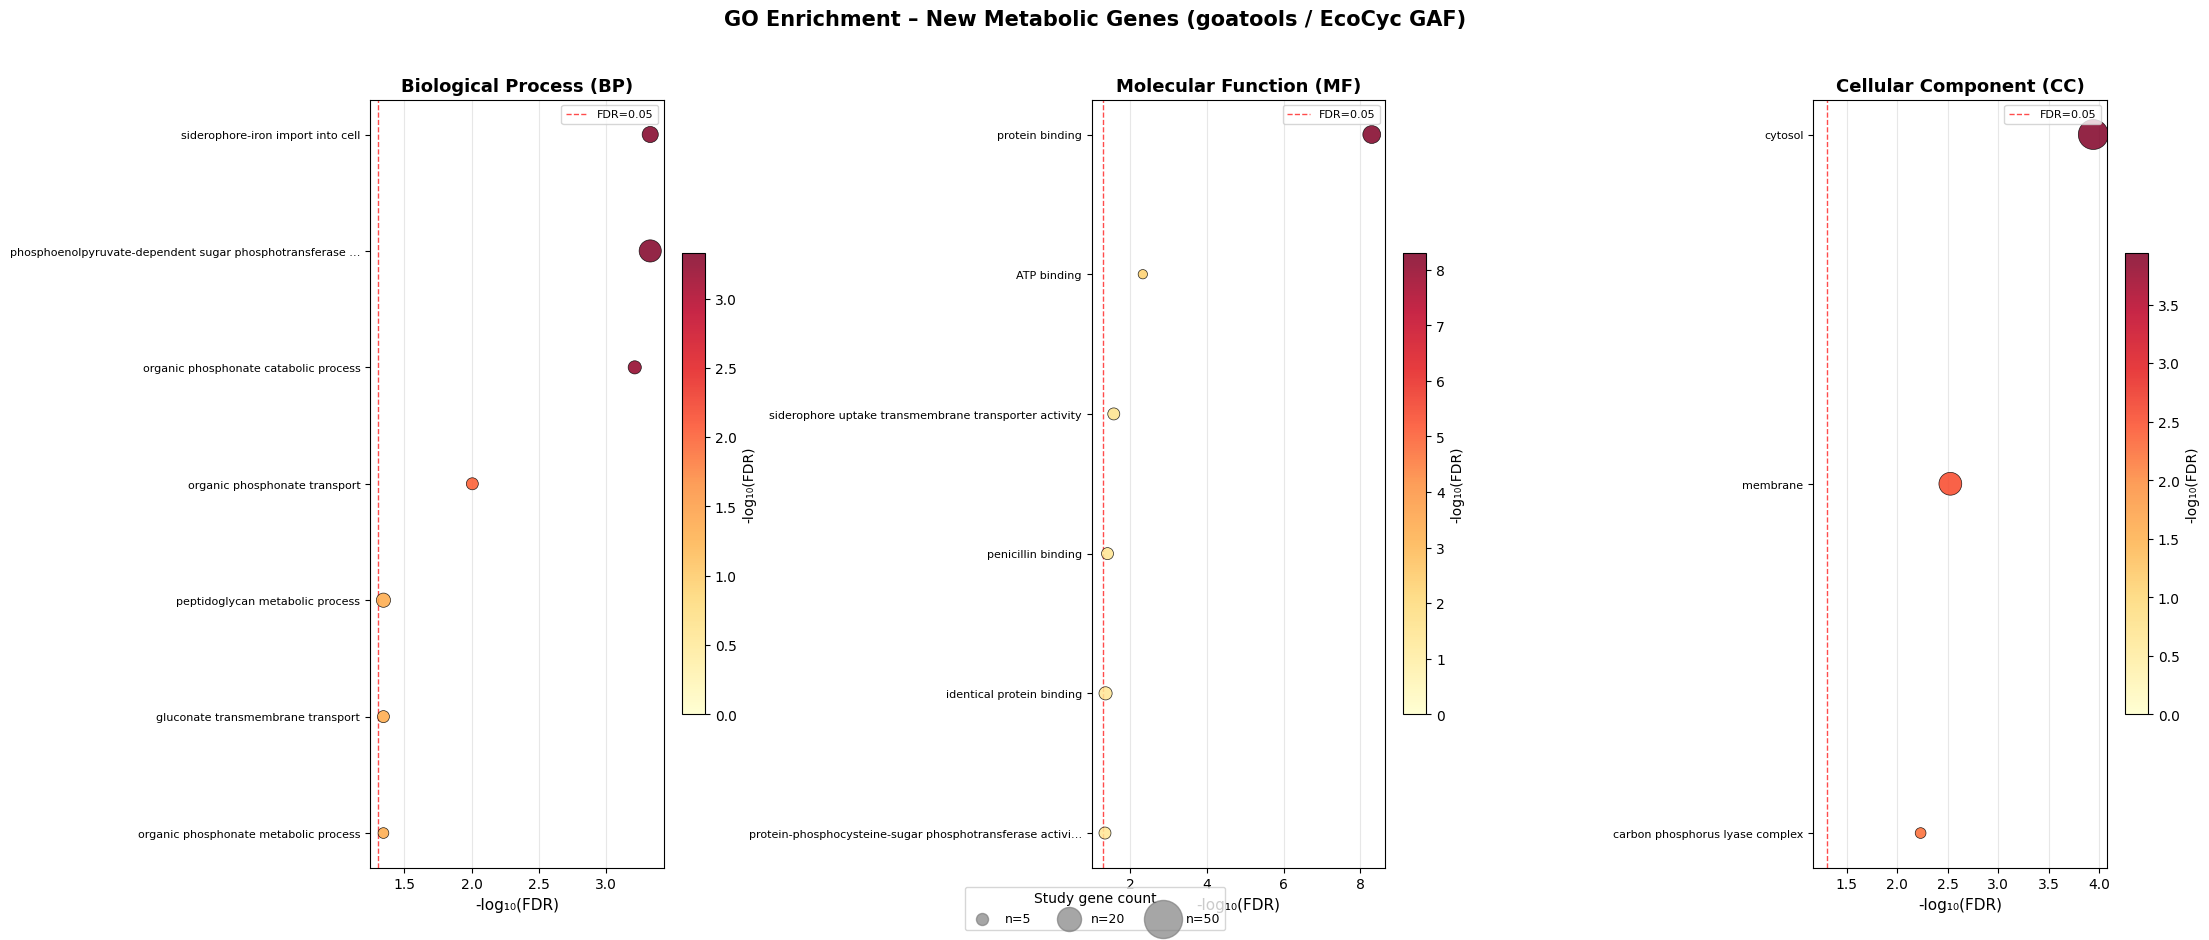

Saved: out/new_genes_functionality/go_enrichment_goatools.svg


In [10]:
import matplotlib.pyplot as plt
import numpy as np

NS_LABELS = {
    "BP": "Biological Process (BP)",
    "MF": "Molecular Function (MF)",
    "CC": "Cellular Component (CC)",
}

if not go_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(22, 9))

    for ax, (ns_key, ns_label) in zip(axes, NS_LABELS.items()):
        ns_data = go_df[go_df["namespace"] == ns_key].head(20).copy()

        if ns_data.empty:
            ax.text(0.5, 0.5, "No significant terms", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12, color="gray")
            ax.set_title(ns_label, fontsize=13, fontweight="bold")
            continue

        ns_data = ns_data.sort_values("p_fdr_bh", ascending=False)
        y_pos   = np.arange(len(ns_data))
        log_p   = -np.log10(ns_data["p_fdr_bh"].clip(lower=1e-300))

        sc = ax.scatter(
            log_p, y_pos,
            s=ns_data["study_count"] * 15,
            c=log_p, cmap="YlOrRd", vmin=0,
            alpha=0.85, edgecolors="black", linewidths=0.5, zorder=3,
        )
        ax.set_yticks(y_pos)
        labels = [t[:55] + "…" if len(t) > 55 else t for t in ns_data["term"]]
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("-log\u2081\u2080(FDR)", fontsize=11)
        ax.set_title(ns_label, fontsize=13, fontweight="bold")
        ax.axvline(-np.log10(0.05), color="red", ls="--", lw=1, alpha=0.7, label="FDR=0.05")
        ax.legend(fontsize=8)
        ax.grid(axis="x", alpha=0.3)
        plt.colorbar(sc, ax=ax, label="-log\u2081\u2080(FDR)", shrink=0.6)

    # Bubble-size legend
    size_vals = [5, 20, 50]
    legend_handles = [
        plt.scatter([], [], s=s * 15, c="gray", alpha=0.7, label=f"n={s}") for s in size_vals
    ]
    fig.legend(handles=legend_handles, title="Study gene count",
               loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.01), fontsize=9)

    plt.suptitle("GO Enrichment – New Metabolic Genes (goatools / EcoCyc GAF)",
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    save_path = outdir / "go_enrichment_goatools.svg"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
else:
    print("No goatools results to visualise.")

### 1b. Complementary approach – gseapy Enrichr

Enrichr uses gene symbols (e.g. *aceA*, *aceB*) rather than EcoCyc IDs. Results are complementary to the goatools analysis above.

Enrichr query: 307 gene symbols
Sample: ['gph', 'hybb', 'fcl', 'moba', 'rhtb', 'osmf']
  GO_Biological_Process_2023 (organism=Escherichia coli) failed: Invalid organism 'escherichia coli'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyces cerevisiae, worm, yeast, zebrafish
  GO_Biological_Process_2023 (no organism filter): 27 terms, 0 significant
  GO_Molecular_Function_2023 (organism=Escherichia coli) failed: Invalid organism 'escherichia coli'. Valid options are: c. elegans, caenorhabditis elegans, celegans, d. melanogaster, d. rerio, danio rerio, drosophila, drosophila melanogaster, enrichr, fish, fly, h. sapiens, homo sapiens, hs, hsapiens, human, m. musculus, mm, mouse, mus musculus, nematode, s. cerevisiae, saccharomyces, saccharomyc

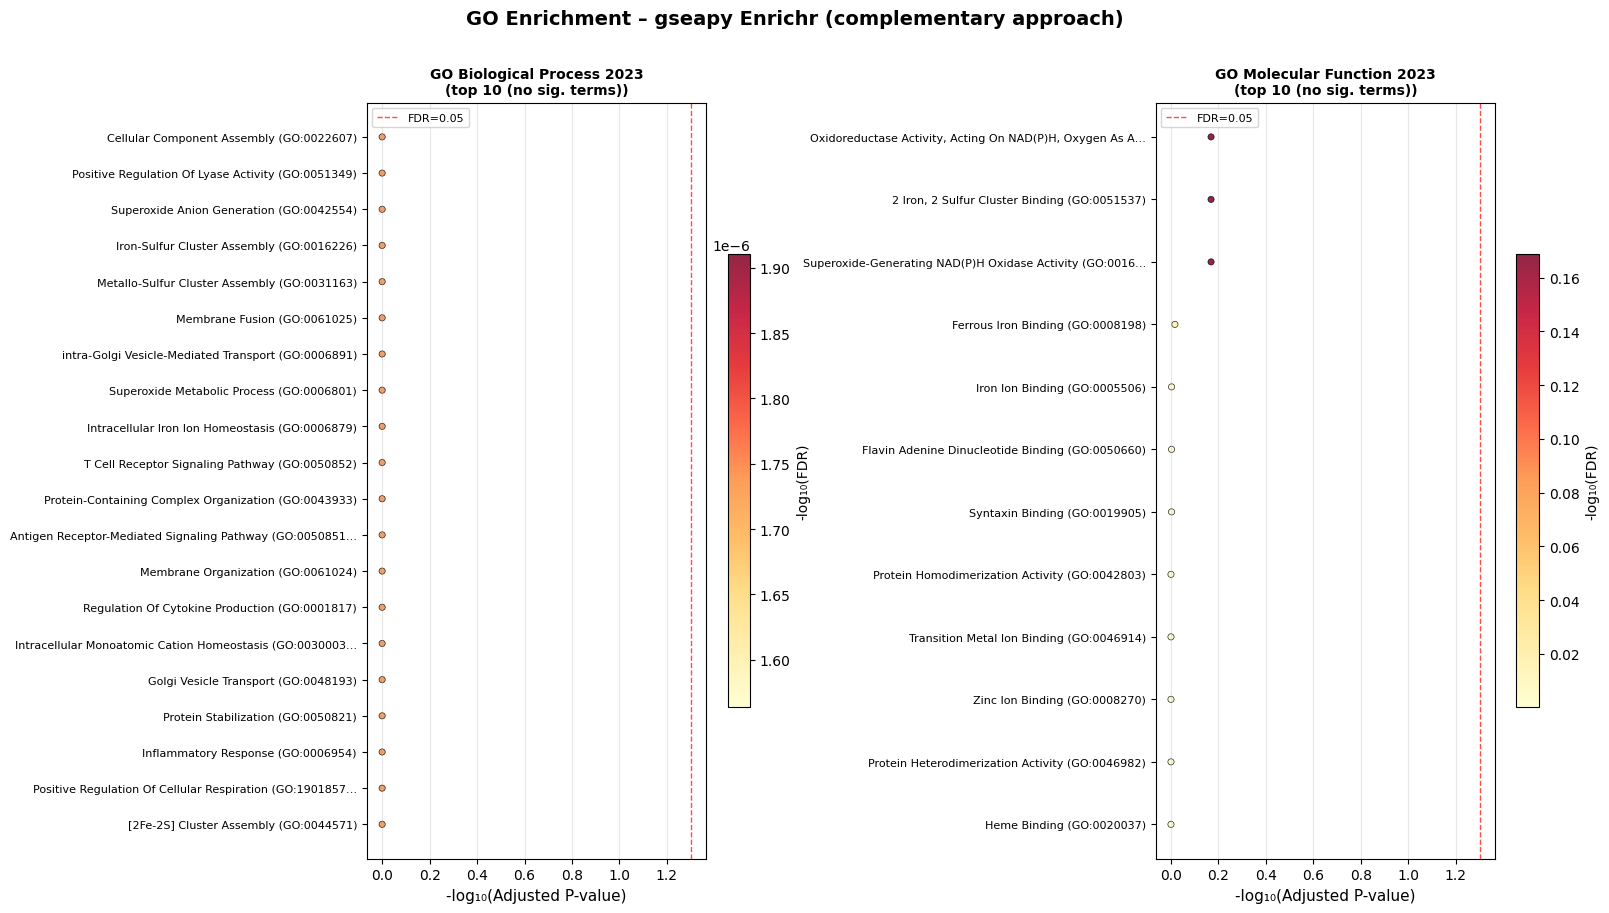

Saved: out/new_genes_functionality/go_enrichment_gseapy.svg


In [26]:
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np

ENRICHR_DBS = [
    "GO_Biological_Process_2023",
    "GO_Molecular_Function_2023",
    "GO_Cellular_Component_2023",
]

gene_list_enrichr = list(study_gene_names)  # lowercase gene symbols
print(f"Enrichr query: {len(gene_list_enrichr)} gene symbols")
print(f"Sample: {gene_list_enrichr[:6]}")

enrichr_results = {}
for db in ENRICHR_DBS:
    for organism in ["Escherichia coli", None]:
        try:
            kwargs = dict(gene_list=gene_list_enrichr, gene_sets=db, outdir=None, verbose=False)
            if organism:
                kwargs["organism"] = organism
            enr = gp.enrichr(**kwargs)
            enrichr_results[db] = enr.results
            sig = enr.results[enr.results["Adjusted P-value"] < 0.05]
            org_str = organism or "(no organism filter)"
            print(f"  {db} {org_str}: {len(enr.results)} terms, {len(sig)} significant")
            break
        except Exception as e:
            print(f"  {db} (organism={organism}) failed: {e}")

if enrichr_results:
    ncols = len(enrichr_results)
    fig, axes = plt.subplots(1, ncols, figsize=(8 * ncols, 9))
    if ncols == 1:
        axes = [axes]

    for ax, (db_name, res_df) in zip(axes, enrichr_results.items()):
        sig_df = res_df[res_df["Adjusted P-value"] < 0.05]
        top    = (sig_df if not sig_df.empty else res_df).head(20).copy()
        top    = top.sort_values("Adjusted P-value", ascending=False)
        top["log_p"] = -np.log10(top["Adjusted P-value"].clip(lower=1e-300))
        top["n_overlap"] = top["Overlap"].apply(
            lambda x: int(x.split("/")[0]) if isinstance(x, str) and "/" in x else 1
        )

        y_pos = np.arange(len(top))
        sc = ax.scatter(
            top["log_p"], y_pos,
            s=top["n_overlap"] * 20,
            c=top["log_p"], cmap="YlOrRd", alpha=0.85,
            edgecolors="black", linewidths=0.5,
        )
        labels = [t[:55] + "…" if len(t) > 55 else t for t in top["Term"]]
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("-log\u2081\u2080(Adjusted P-value)", fontsize=11)
        ax.axvline(-np.log10(0.05), color="red", ls="--", lw=1, alpha=0.7, label="FDR=0.05")
        ax.legend(fontsize=8)
        ax.grid(axis="x", alpha=0.3)
        title_suffix = "FDR<0.05" if not sig_df.empty else "top 10 (no sig. terms)"
        ax.set_title(f"{db_name.replace('_', ' ')}\n({title_suffix})", fontsize=10, fontweight="bold")
        plt.colorbar(sc, ax=ax, label="-log\u2081\u2080(FDR)", shrink=0.6)

    plt.suptitle("GO Enrichment – gseapy Enrichr (complementary approach)",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    save_path = outdir / "go_enrichment_gseapy.svg"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
else:
    print("No Enrichr results obtained.")

## 2. KEGG Pathway Enrichment

In [27]:
import requests
import pandas as pd

kegg_link_path = tmpdir / "kegg_eco_pathway_genes.tsv"
kegg_list_path = tmpdir / "kegg_eco_pathway_names.tsv"

def _kegg_get(url, cache_path, label):
    if not cache_path.exists():
        print(f"Downloading {label}...")
        try:
            r = requests.get(url, timeout=90)
            r.raise_for_status()
            cache_path.write_text(r.text, encoding="utf-8")
            print(f"  {len(r.text.splitlines())} entries saved to {cache_path}")
            return cache_path
        except Exception as e:
            print(f"  WARNING: {e}")
            return None
    else:
        print(f"Using cached {label}: {cache_path}")
        return cache_path

kegg_link_path = _kegg_get(
    "https://rest.kegg.jp/link/eco/pathway", kegg_link_path, "KEGG pathway-gene links"
)
kegg_list_path = _kegg_get(
    "https://rest.kegg.jp/list/pathway/eco", kegg_list_path, "KEGG pathway names"
)

kegg_link_df    = pd.DataFrame()
pathway_name_map = {}
kegg_study_genes = set()
kegg_background  = set()

if kegg_link_path is not None:
    kegg_link_df = pd.read_csv(
        kegg_link_path, sep="\t", header=None, names=["pathway_id", "gene_id"]
    )
    # gene_id format: eco:b4015 → strip prefix
    kegg_link_df["locus_id"]      = kegg_link_df["gene_id"].str.replace("eco:", "", regex=False)
    kegg_link_df["pathway_short"] = kegg_link_df["pathway_id"].str.replace("path:", "", regex=False)
    kegg_background = set(kegg_link_df["locus_id"].unique())
    kegg_study_genes = study_locus_ids & kegg_background
    print(f"KEGG: {kegg_link_df['pathway_short'].nunique()} pathways, "
          f"{len(kegg_background)} background genes")
    print(f"Study genes matched: {len(kegg_study_genes)} / {len(study_locus_ids)}")

if kegg_list_path is not None:
    names_df = pd.read_csv(kegg_list_path, sep="\t", header=None, names=["pathway_id", "pathway_name"])
    names_df["pathway_short"] = names_df["pathway_id"].str.replace("path:", "", regex=False)
    pathway_name_map = dict(zip(names_df["pathway_short"], names_df["pathway_name"]))
    print(f"Loaded {len(pathway_name_map)} pathway names")

  4964 entries saved to tmp/kegg_eco_pathway_genes.tsv
  137 entries saved to tmp/kegg_eco_pathway_names.tsv
KEGG: 137 pathways, 1785 background genes
Study genes matched: 206 / 307
Loaded 137 pathway names


In [28]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import numpy as np

kegg_enrich_df = pd.DataFrame()

if not kegg_link_df.empty and len(kegg_study_genes) > 0:
    N = len(kegg_background)
    K = len(kegg_study_genes)

    rows = []
    for pw, grp in kegg_link_df.groupby("pathway_short"):
        pw_genes = set(grp["locus_id"])
        a = len(kegg_study_genes & pw_genes)  # study in pathway
        b = len(pw_genes) - a                  # pop-only in pathway
        c = K - a                               # study not in pathway
        d = N - K - b                           # pop-only, not in pathway
        if a == 0:
            continue
        _, pval = fisher_exact([[a, b], [c, max(d, 0)]], alternative="greater")
        rows.append({
            "pathway_id":       pw,
            "pathway_name":     pathway_name_map.get(pw, pw),
            "study_in_pathway": a,
            "pathway_size":     len(pw_genes),
            "p_value":          pval,
        })

    kegg_enrich_df = pd.DataFrame(rows)
    if not kegg_enrich_df.empty:
        _, fdr, _, _ = multipletests(kegg_enrich_df["p_value"], method="fdr_bh")
        kegg_enrich_df["p_fdr"] = fdr
        kegg_enrich_df = kegg_enrich_df.sort_values("p_fdr")
        sig_k = kegg_enrich_df[kegg_enrich_df["p_fdr"] < 0.05]
        print(f"KEGG pathways tested: {len(kegg_enrich_df)}, significant (FDR<0.05): {len(sig_k)}")
        print("\nTop 15 KEGG pathways:")
        print(kegg_enrich_df.head(15)[
            ["pathway_name", "study_in_pathway", "pathway_size", "p_fdr"]
        ].to_string(index=False))
else:
    print("Skipping KEGG enrichment: no data.")

KEGG pathways tested: 70, significant (FDR<0.05): 13

Top 15 KEGG pathways:
                                                          pathway_name  study_in_pathway  pathway_size    p_fdr
        Phosphotransferase system (PTS) - Escherichia coli K-12 MG1655                19            43 0.000003
 Phosphonate and phosphinate metabolism - Escherichia coli K-12 MG1655                 7             8 0.000042
                       ABC transporters - Escherichia coli K-12 MG1655                42           179 0.000042
      Degradation of aromatic compounds - Escherichia coli K-12 MG1655                10            17 0.000056
         Exopolysaccharide biosynthesis - Escherichia coli K-12 MG1655                 8            15 0.001212
                    Folate biosynthesis - Escherichia coli K-12 MG1655                10            26 0.003388
               Nitrotoluene degradation - Escherichia coli K-12 MG1655                 5             7 0.003388
      Ascorbate and aldarate

In [34]:
kegg_enrich_df

,pathway_id,pathway_name,study_in_pathway,pathway_size,p_value,p_fdr
67,eco02060,Phosphotransferase system (PTS) - Escherichia ...,19,43,4.440815e-08,0.000003
14,eco00440,Phosphonate and phosphinate metabolism - Esche...,7,8,1.795980e-06,0.000042
64,eco02010,ABC transporters - Escherichia coli K-12 MG1655,42,179,1.347664e-06,0.000042
57,eco01220,Degradation of aromatic compounds - Escherichi...,10,17,3.196132e-06,0.000056
24,eco00543,Exopolysaccharide biosynthesis - Escherichia c...,8,15,8.655511e-05,0.001212
...,...,...,...,...,...,...
29,eco00564,Glycerophospholipid metabolism - Escherichia c...,1,29,9.722963e-01,1.000000
17,eco00480,Glutathione metabolism - Escherichia coli K-12...,1,24,9.483571e-01,1.000000
49,eco00970,Aminoacyl-tRNA biosynthesis - Escherichia coli...,1,111,9.999992e-01,1.000000
45,eco00900,Terpenoid backbone biosynthesis - Escherichia ...,1,14,8.215524e-01,1.000000


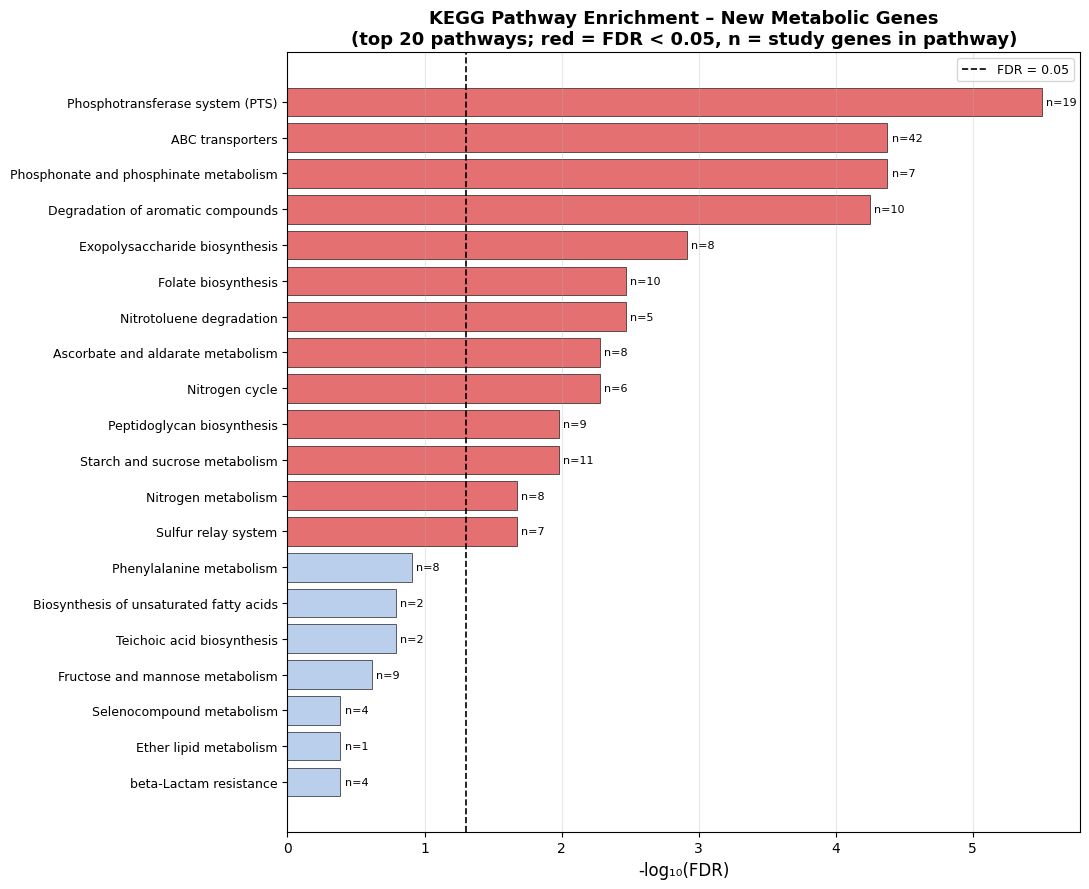

Saved: out/new_genes_functionality/kegg_enrichment.svg


In [32]:
import matplotlib.pyplot as plt
import numpy as np

if not kegg_enrich_df.empty:
    top20 = kegg_enrich_df.head(20).copy().sort_values("p_fdr", ascending=False)
    top20["log_p"] = -np.log10(top20["p_fdr"].clip(lower=1e-300))

    colors = ["#e15759" if p < 0.05 else "#aec7e8" for p in top20["p_fdr"]]

    fig, ax = plt.subplots(figsize=(11, 9))
    ax.barh(range(len(top20)), top20["log_p"],
            color=colors, edgecolor="black", linewidth=0.5, alpha=0.85)

    for i, (_, row) in enumerate(top20.iterrows()):
        ax.text(row["log_p"] + 0.03, i, f"n={int(row['study_in_pathway'])}",
                va="center", fontsize=8)

    clean_names = []
    for name in top20["pathway_name"]:
        short = name.split(" - ")[0] if " - " in name else name
        clean_names.append(short[:62] + "…" if len(short) > 62 else short)

    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(clean_names, fontsize=9)
    ax.set_xlabel("-log\u2081\u2080(FDR)", fontsize=12)
    ax.set_title(
        "KEGG Pathway Enrichment – New Metabolic Genes\n"
        "(top 20 pathways; red = FDR < 0.05, n = study genes in pathway)",
        fontsize=13, fontweight="bold",
    )
    ax.axvline(-np.log10(0.05), color="black", ls="--", lw=1.2, label="FDR = 0.05")
    ax.legend(fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    save_path = outdir / "kegg_enrichment.svg"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
else:
    print("No KEGG results to visualise.")

## 3. RegulonDB Regulon Mapping

In [33]:
import requests

regulon_path = tmpdir / "network_tf_gene.txt"
REGULON_URLS = [
    "https://regulondb.ccg.unam.mx/menu/download/datasets/files/network_tf_gene.txt",
    "https://regulondb.ccg.unam.mx/menu/download/datasets/files/NetworkTFGene.txt",
    "https://regulondb.ccg.unam.mx/webresources/regulon/network_tf_gene",
]

if not regulon_path.exists():
    downloaded = False
    for url in REGULON_URLS:
        print(f"Trying {url}...")
        try:
            r = requests.get(url, timeout=60,
                             headers={"User-Agent": "Mozilla/5.0"})
            r.raise_for_status()
            regulon_path.write_bytes(r.content)
            print(f"  Downloaded ({len(r.content)//1024} KB)")
            downloaded = True
            break
        except Exception as e:
            print(f"  Failed: {e}")
    if not downloaded:
        print("WARNING: Could not download RegulonDB – skipping section 3.")
        regulon_path = None
else:
    print(f"Using cached RegulonDB file: {regulon_path}")

if regulon_path is not None:
    with open(regulon_path, "r", errors="replace") as f:
        raw_lines = f.readlines()
    data_preview = [l for l in raw_lines if not l.startswith("#")][:4]
    print("\nFile preview (first 4 data lines):")
    for l in data_preview:
        print(f"  {repr(l[:120])}")

Trying https://regulondb.ccg.unam.mx/menu/download/datasets/files/network_tf_gene.txt...
  Failed: HTTPSConnectionPool(host='regulondb.ccg.unam.mx', port=443): Max retries exceeded with url: /menu/download/datasets/files/network_tf_gene.txt (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))
Trying https://regulondb.ccg.unam.mx/menu/download/datasets/files/NetworkTFGene.txt...
  Failed: HTTPSConnectionPool(host='regulondb.ccg.unam.mx', port=443): Max retries exceeded with url: /menu/download/datasets/files/NetworkTFGene.txt (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))
Trying https://regulondb.ccg.unam.mx/webresources/regulon/network_tf_gene...
  Failed: HTTPSConnectionPool(host='regulondb.ccg.unam.mx', port=443): Max retries exceeded with url: /webresourc

In [ ]:
import pandas as pd
import collections
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

regulon_df   = pd.DataFrame()
tf_summary   = pd.DataFrame()
tf_enrich_df = pd.DataFrame()
regulon_study  = set()
regulon_bg     = set()
tf_effects     = {}

if regulon_path is not None:
    data_lines = [l for l in raw_lines if not l.startswith("#") and l.strip()]

    records = []
    for line in data_lines:
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            records.append({
                "tf_name":  parts[0].strip(),
                "gene_name": parts[1].strip().lower(),
                "effect":   parts[2].strip() if len(parts) > 2 else "?",
            })

    regulon_df = pd.DataFrame(records)
    print(f"Parsed {len(regulon_df)} TF-gene interactions")
    print(f"Unique TFs: {regulon_df['tf_name'].nunique()}, "
          f"Unique genes: {regulon_df['gene_name'].nunique()}")
    print(f"Effect values: {regulon_df['effect'].value_counts().to_dict()}")

    regulon_bg    = set(regulon_df["gene_name"].unique())
    regulon_study = study_gene_names & regulon_bg
    print(f"\nStudy genes matched in RegulonDB: {len(regulon_study)} / {len(study_gene_names)}")

    # Per-TF summary
    tf_rows = []
    for tf, grp in regulon_df.groupby("tf_name"):
        tf_genes = set(grp["gene_name"])
        eff_counts = grp["effect"].value_counts()
        top_eff = eff_counts.index[0] if len(eff_counts) else "?"
        if "+" in top_eff and "-" in top_eff:
            dom_effect = "dual"
        elif "+" in top_eff:
            dom_effect = "activator"
        elif "-" in top_eff:
            dom_effect = "repressor"
        else:
            dom_effect = "unknown"
        tf_effects[tf] = dom_effect
        tf_rows.append({
            "TF": tf,
            "study_count": len(tf_genes & regulon_study),
            "regulon_size": len(tf_genes),
            "effect": dom_effect,
        })
    tf_summary = pd.DataFrame(tf_rows).sort_values("study_count", ascending=False)

    # Fisher exact test per TF
    N_reg = len(regulon_bg)
    K_reg = len(regulon_study)
    enrich_rows = []
    for tf, grp in regulon_df.groupby("tf_name"):
        tf_genes = set(grp["gene_name"])
        a = len(tf_genes & regulon_study)
        if a == 0:
            continue
        b = len(tf_genes) - a
        c = K_reg - a
        d = max(N_reg - K_reg - b, 0)
        _, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
        enrich_rows.append({
            "TF": tf, "study_count": a,
            "regulon_size": len(tf_genes),
            "effect": tf_effects[tf], "p_value": pval,
        })
    tf_enrich_df = pd.DataFrame(enrich_rows)
    if not tf_enrich_df.empty:
        _, fdr, _, _ = multipletests(tf_enrich_df["p_value"], method="fdr_bh")
        tf_enrich_df["p_fdr"] = fdr
        tf_enrich_df = tf_enrich_df.sort_values("p_fdr")
        sig_tfs = tf_enrich_df[tf_enrich_df["p_fdr"] < 0.05]
        print(f"\nTFs tested: {len(tf_enrich_df)}, significant (FDR<0.05): {len(sig_tfs)}")
        print("\nTop 15 enriched TFs:")
        print(tf_enrich_df.head(15)[
            ["TF", "study_count", "regulon_size", "effect", "p_fdr"]
        ].to_string(index=False))
else:
    print("RegulonDB data unavailable – skipping.")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

EFFECT_COLORS = {
    "activator": "#4e79a7",
    "repressor": "#e15759",
    "dual":      "#f28e2b",
    "unknown":   "#bab0ac",
}

if not tf_summary.empty:
    fig, axes = plt.subplots(1, 3, figsize=(24, 9))

    # ── Plot 1: barplot top 20 TFs by study count ──────────────────────────
    ax1 = axes[0]
    top20 = tf_summary[tf_summary["study_count"] > 0].head(20).copy()
    top20 = top20.sort_values("study_count")
    bar_col = [EFFECT_COLORS.get(e, "#bab0ac") for e in top20["effect"]]
    ax1.barh(range(len(top20)), top20["study_count"],
             color=bar_col, edgecolor="black", linewidth=0.5, alpha=0.85)
    ax1.set_yticks(range(len(top20)))
    ax1.set_yticklabels(top20["TF"], fontsize=9)
    ax1.set_xlabel("Number of new genes regulated", fontsize=11)
    ax1.set_title("Top 20 TFs Regulating New Genes", fontsize=12, fontweight="bold")
    patches = [mpatches.Patch(color=c, label=e)
               for e, c in EFFECT_COLORS.items() if e != "unknown"]
    ax1.legend(handles=patches, fontsize=8, loc="lower right")
    ax1.grid(axis="x", alpha=0.3)

    # ── Plot 2: enrichment dot plot ────────────────────────────────────────
    ax2 = axes[1]
    if not tf_enrich_df.empty:
        top_enrich = tf_enrich_df.head(20).copy().sort_values("p_fdr", ascending=False)
        top_enrich["log_p"] = -np.log10(top_enrich["p_fdr"].clip(lower=1e-300))
        sc_col = [EFFECT_COLORS.get(e, "#bab0ac") for e in top_enrich["effect"]]
        ax2.scatter(
            top_enrich["log_p"], range(len(top_enrich)),
            s=top_enrich["study_count"] * 25,
            c=sc_col, edgecolors="black", linewidths=0.5, alpha=0.85, zorder=3,
        )
        ax2.set_yticks(range(len(top_enrich)))
        ax2.set_yticklabels(top_enrich["TF"], fontsize=9)
        ax2.set_xlabel("-log\u2081\u2080(FDR)", fontsize=11)
        ax2.axvline(-np.log10(0.05), color="red", ls="--", lw=1, alpha=0.7, label="FDR=0.05")
        ax2.legend(fontsize=8)
        ax2.grid(axis="x", alpha=0.3)
        ax2.set_title("TF Regulon Enrichment (Fisher exact)", fontsize=12, fontweight="bold")
    else:
        ax2.text(0.5, 0.5, "No enrichment data", ha="center", va="center",
                 transform=ax2.transAxes, color="gray")

    # ── Plot 3: pie chart – activator / repressor / dual breakdown ─────────
    ax3 = axes[2]
    sig_subset = tf_enrich_df[tf_enrich_df["p_fdr"] < 0.05] if not tf_enrich_df.empty else pd.DataFrame()
    if not sig_subset.empty:
        eff_counts = sig_subset["effect"].value_counts()
        title_sfx  = "(FDR < 0.05 TFs)"
    else:
        eff_counts = tf_summary[tf_summary["study_count"] > 0]["effect"].value_counts()
        title_sfx  = "(all TFs with study genes)"
    pie_col = [EFFECT_COLORS.get(e, "#bab0ac") for e in eff_counts.index]
    wedges, texts, autotexts = ax3.pie(
        eff_counts.values, labels=eff_counts.index,
        colors=pie_col, autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor": "black", "linewidth": 0.7},
    )
    for at in autotexts:
        at.set_fontsize(9)
    ax3.set_title(f"TF Effect Categories\n{title_sfx}", fontsize=12, fontweight="bold")

    plt.suptitle("RegulonDB Regulon Mapping – New Metabolic Genes",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    save_path = outdir / "regulondb_analysis.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
else:
    print("No RegulonDB results to visualise.")